# Customer Churn Prediction — Random Forest (Corrected: No Leakage)

**Goal:** Predict which customers are likely to go quiet in the *next* 90 days, using only what we knew about them *before* that window started.

**What was wrong before:** the old label (`Churn = 1 if Segment in ["At Risk","Lost"]`) was computed from the same Recency/Frequency/Monetary values used as features — so the model was just re-deriving a rule it was handed, not predicting anything about the future. That's why accuracy/ROC-AUC were unrealistically high (96%, 0.9955) and every dashboard prediction came out as 0% or ~100%.

**The fix — time-based split:**
- Pick a cutoff date, e.g. 90 days before the last transaction in the dataset.
- Compute Recency/Frequency/Monetary using only transactions **before** the cutoff (the model's features — what we "knew" at the time).
- Define the label using transactions **after** the cutoff: did the customer make *any* purchase in that window? If not, they churned.
- The model now predicts something genuinely unknown at feature-computation time, so a high score actually means something.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


## Step 1 — Load and clean the raw transactions (same cleaning as the EDA notebook)

In [2]:
df = pd.read_csv("../data/online_retail.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

df = df.dropna(subset=["CustomerID"])
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalRevenue"] = (df["Quantity"] * df["UnitPrice"]).round(2)

print(f"Clean rows: {len(df):,}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")


Clean rows: 397,884
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


## Step 2 — Pick the cutoff date

We use the last 90 days of the dataset as the "future" window we're trying to predict into.
Everything before the cutoff is used to build features; everything after is used only to build the label.


In [3]:
last_date = df["InvoiceDate"].max()
cutoff_date = last_date - pd.Timedelta(days=90)

print(f"Last transaction date: {last_date}")
print(f"Cutoff date: {cutoff_date}")
print(f"Feature window:  before {cutoff_date.date()}")
print(f"Label window:    {cutoff_date.date()} to {last_date.date()}")

pre_cutoff = df[df["InvoiceDate"] < cutoff_date]
post_cutoff = df[df["InvoiceDate"] >= cutoff_date]

print(f"\nTransactions before cutoff: {len(pre_cutoff):,}")
print(f"Transactions after cutoff:  {len(post_cutoff):,}")


Last transaction date: 2011-12-09 12:50:00
Cutoff date: 2011-09-10 12:50:00
Feature window:  before 2011-09-10
Label window:    2011-09-10 to 2011-12-09

Transactions before cutoff: 236,358
Transactions after cutoff:  161,526


## Step 3 — Build features from the PRE-cutoff window only

This is exactly the same RFM logic as before, but computed as of the cutoff date, not the true last date —
so these numbers reflect only what we "knew" at prediction time.


In [4]:
features = (pre_cutoff
    .groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (cutoff_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalRevenue", "sum")
    )
    .reset_index()
)
features["Monetary"] = features["Monetary"].round(2)

print(f"Customers with activity before cutoff: {len(features):,}")
features.head()


Customers with activity before cutoff: 3,370


,CustomerID,Recency,Frequency,Monetary
0,12346.0,235,1,77183.60
1,12347.0,39,5,2790.86
2,12348.0,158,3,1487.24
3,12350.0,219,1,334.40
4,12352.0,171,5,1561.81


## Step 4 — Build the label from the POST-cutoff window

A customer "churned" if they made **zero** purchases in the 90 days after the cutoff.
Only customers who were actually active pre-cutoff are included — we can't say someone
"churned" if they were never a customer to begin with.


In [5]:
active_after_cutoff = set(post_cutoff["CustomerID"].unique())

features["Churn"] = features["CustomerID"].apply(
    lambda cid: 0 if cid in active_after_cutoff else 1
)

print(f"Churned: {features['Churn'].sum():,} ({features['Churn'].mean()*100:.1f}%)")
print(f"Active:  {(features['Churn']==0).sum():,} ({(features['Churn']==0).mean()*100:.1f}%)")


Churned: 1,449 (43.0%)
Active:  1,921 (57.0%)


## Step 5 — Train the model

Features and label now come from **non-overlapping time windows**, so there's no leakage —
the model has to genuinely generalize from past behavior to future behavior.


In [6]:
X = features[["Recency", "Frequency", "Monetary"]]
y = features["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

print("Training complete!")
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Training complete!
Train size: 2696 | Test size: 674


In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# Sanity check: a real model should show a SPREAD of probabilities, not just 0%/100%
print("\nProbability distribution check:")
print(pd.Series(y_prob).describe())


Classification Report:
              precision    recall  f1-score   support

      Active       0.67      0.68      0.67       384
     Churned       0.57      0.55      0.56       290

    accuracy                           0.62       674
   macro avg       0.62      0.62      0.62       674
weighted avg       0.62      0.62      0.62       674

ROC-AUC Score: 0.6711

Probability distribution check:
count    674.000000
mean       0.426647
std        0.292868
min        0.000000
25%        0.150000
50%        0.425000
75%        0.677500
max        1.000000
dtype: float64


**What to expect now:** ROC-AUC in a realistic 0.65–0.85 range (not 0.99+), and a genuine spread of
probabilities in the distribution check above — not a pile-up at 0.0 and 1.0. If it's still near-perfect,
that's a sign there's another leakage source to hunt down (e.g. Recency close to the cutoff itself
mechanically correlating with the label window).


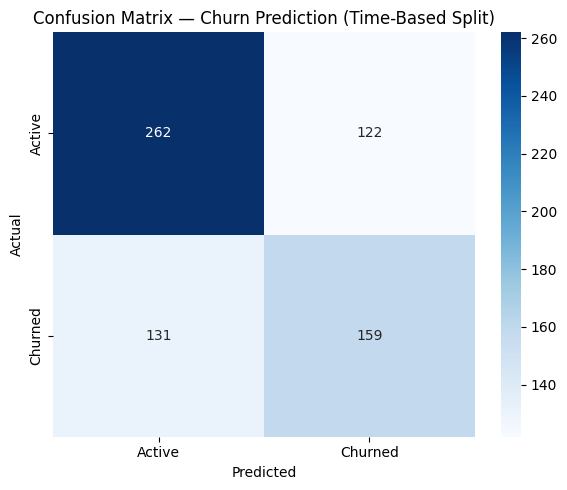

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active", "Churned"],
            yticklabels=["Active", "Churned"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Churn Prediction (Time-Based Split)")
plt.tight_layout()
plt.savefig("../output/confusion_matrix.png", dpi=150)
plt.show()


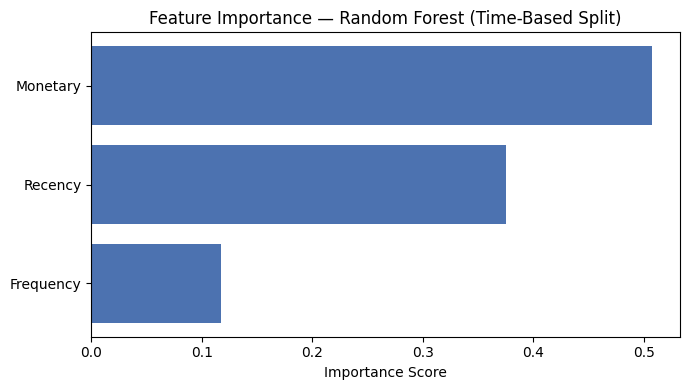

In [9]:
feat_importance = pd.DataFrame({
    "Feature": ["Recency", "Frequency", "Monetary"],
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(feat_importance["Feature"], feat_importance["Importance"], color="#4C72B0")
ax.set_xlabel("Importance Score")
ax.set_title("Feature Importance — Random Forest (Time-Based Split)")
plt.tight_layout()
plt.savefig("../output/feature_importance.png", dpi=150)
plt.show()


## Step 6 — Score CURRENT customers for the dashboard

For the live "who's at risk right now" view, recompute RFM using the **full dataset up to the true last date**
(not the training cutoff) — this reflects each customer's real, current status — then apply the trained model.
This is now a genuine forward-looking prediction: "who is likely to go quiet in the next 90 days," not a
restatement of their current segment.


In [10]:
current_features = (df
    .groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (last_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalRevenue", "sum")
    )
    .reset_index()
)
current_features["Monetary"] = current_features["Monetary"].round(2)

current_features["Churn_Probability"] = model.predict_proba(
    current_features[["Recency", "Frequency", "Monetary"]]
)[:, 1]

high_risk = (current_features
    .sort_values("Churn_Probability", ascending=False)
    .head(10)
    [["CustomerID", "Recency", "Frequency", "Monetary", "Churn_Probability"]]
    .reset_index(drop=True)
)

display_df = high_risk.copy()
display_df["Churn_Probability"] = display_df["Churn_Probability"].apply(lambda x: f"{x:.1%}")
display_df["Monetary"] = display_df["Monetary"].apply(lambda x: f"£{x:,.2f}")
print(display_df.to_string())

current_features.to_csv("../output/current_churn_scores.csv", index=False)
print("\nSaved current churn scores for dashboard use.")


   CustomerID  Recency  Frequency Monetary Churn_Probability
0     17995.0      281          1   £76.10            100.0%
1     13833.0      158          1  £384.80            100.0%
2     13887.0      203          1  £349.55             99.0%
3     16967.0      188          1  £319.02             99.0%
4     12851.0       96          1  £135.18             99.0%
5     13099.0       98          1  £207.36             99.0%
6     14622.0      184          1  £320.58             99.0%
7     17693.0      136          1  £200.47             99.0%
8     13774.0       81          1  £345.00             99.0%
9     15348.0       71          1  £158.04             99.0%

Saved current churn scores for dashboard use.
